# Deterministic-model verification: POD / FAR / SEDI maps

Global maps of **POD**, **FAR**, and **SEDI** for the deterministic
**AIFS-single-v2** reforecast
(`/net/monsoon/marchakitus/reforecast/forecasts_AIFS_v2`, opened via
`aifs_singlev2.open_aifs_singlev2()`) against ERA5, at lead days
**1, 3, 5, 7, 9**, over `test_year_start`-`test_year_end`.

**`test_year_start`/`test_year_end` and `region_bounds` (see the Step 0
config cell) are the two settings to change between runs** -- no separate
demo/full switch: set `region_bounds` to a small box (e.g. the Delhi, India
default) and/or a narrow year range for a fast run, or `region_bounds = None`
(or the environment variable `REGION_BOUNDS=global`) with a wide year range
for the real global/full-year thing. A small region keeps every step cheap
regardless of how many initializations it covers (Step 3 takes advantage of
this -- see there), so there's no need for anything beyond these two
settings to get a fast, representative run.

All of these (plus the dask cluster's `n_workers`/`threads_per_worker`/
`memory_limit`, `variable`, and `relative_percentile` below) can also be set
from **outside** this notebook via environment variables (`TEST_YEAR_START`,
`TEST_YEAR_END`, `REGION_BOUNDS`, `N_WORKERS`, `THREADS_PER_WORKER`,
`MEMORY_LIMIT`, `VARIABLE`, `RELATIVE_PERCENTILE`) instead of editing the
Step 0 cells directly -- see `run_notebook.slurm`, which sets these before
regenerating and executing this notebook so a batch run's parameters live in
the Slurm submit script, not in this file.

*RMSE is commented out for now* (uncomment `squared_error`/
`rmse_from_mean_squared_error`/the `rmse_*` lines in Steps 4, 5, and 7 to
bring it back) -- both threshold definitions below are otherwise active.

**Extreme-event variable is selectable** (`variable` in Step 0, or the
`VARIABLE` environment variable): `t2m_mean_6h` (daily mean, the default),
`t2m_max_6h` (daily max), or `t2m_min_6h` (daily min) 2m air temperature --
all three are computed regardless of which is selected (Step 2). Threshold
definitions currently active:

- **Absolute**: `variable > 35`degC, always.
- **Relative** (`variable` above `relative_percentile` -- 0.95, 0.99, or
  0.999, default 0.95, also settable via the `RELATIVE_PERCENTILE`
  environment variable -- of its 1979-2018 daily climatology at that grid
  cell and day of year): automatic whenever `variable` is `t2m_max_6h` or
  `t2m_min_6h`, since a precomputed climatology file exists for those (from
  `/net/monsoon/aasch/percentiles/`, via
  `climatology.open_percentile_climatology`). **Skipped** when `variable`
  is `t2m_mean_6h` -- there's no precomputed daily-mean climatology file, so
  that case runs absolute-only. No separate on/off switch: this follows
  automatically from `variable`.

**Steps below, each runnable and inspectable on its own:**

0. Setup -- imports, config, dask cluster.
1. Load data -- raw model and ERA5 datasets, untouched.
2. Preprocess and align -- units, daily aggregation, spatial grid alignment.
3. Examine the variable of interest -- a small `model_var`/`era5_var` sample,
   before running anything expensive, to sanity-check the data makes sense.
4. Calculate H, M, F, C -- batched over initializations.
5. Calculate POD, FAR, SEDI.
6. Sanity checks -- range/consistency checks on the results themselves.
7. Plotting.

Self-contained: does not import the `heatextremes` package (a shared,
read-only dependency here) -- see `deterministic_metrics.py` and
`era5_loader.py` for the small amount of logic copied locally instead.

**Not executed in this environment:** this notebook needs `/net/monsoon/...`
and the real AIFS-single-v2/ERA5 data stores, neither of which is reachable
here, so cells below were written, unit-tested against synthetic arrays (see
the accompanying module tests), and syntax-checked, but not run end-to-end
against real data. In particular:

- `aifs_singlev2.open_aifs_singlev2()`'s glob pattern/chunking is adapted
  from the ensemble loader but not verified against the real store.
- The climatology computation (one quantile reduction per day of year, over
  22 years of global 0.25-degree daily data) is expensive; consider
  persisting `threshold_by_doy` to disk after computing it once, rather
  than recomputing it on every run.

## Step 0: Setup

Imports, configuration, and the dask cluster. The settings you'll actually
change between runs are `test_year_start`/`test_year_end` (inclusive; set
them equal for a single year, or apart for a multi-year run), `region_bounds`
(a `(south, north, west, east)` box in degrees, or `None` for the full global
grid), and `variable` (`t2m_mean_6h`, `t2m_max_6h`, or `t2m_min_6h`).

In [7]:
import csv
import os
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from zarr.errors import ZarrUserWarning

from era5_loader import open_cached_era5, daily_era5_aggregates  # local, no heatextremes dependency

from aifs_singlev2 import open_aifs_singlev2, daily_aifs_aggregates_calendar_aligned
from climatology import open_percentile_climatology, threshold_at_verification_time  # local relative-threshold helpers
from deterministic_metrics import (
    extreme_indicators,
    false_alarm_ratio,
    mean_in_time_batches,  # local copy, no heatextremes dependency -- see deterministic_metrics.py
    probability_of_detection,
    probability_of_false_detection,
    verification_time,  # used in Step 3 to find the ERA5 dates a model sample verifies against
    # rmse_from_mean_squared_error,  # RMSE commented out for now -- see calculate_scores/finish-metrics cells
    # squared_error,  # RMSE commented out for now -- see calculate_scores/finish-metrics cells
    symmetric_extremal_dependence_index,
)

# --- The settings you'll actually change between runs ---
# Each reads an environment variable first, falling back to the hardcoded
# default if that variable isn't set -- so a Slurm submit script can control
# these without editing this file (see run_notebook.slurm, which sets
# TEST_YEAR_START/TEST_YEAR_END/REGION_BOUNDS before generating this
# notebook). Editing the defaults below still works fine for interactive use.
test_year_start = int(os.environ.get("TEST_YEAR_START", 2022))
test_year_end = int(os.environ.get("TEST_YEAR_END", 2022))  # inclusive; > test_year_start for multi-year

# Region to restrict both model and ERA5 to, as (south, north, west, east) in
# degrees -- e.g. the Delhi, India default below. A small region keeps every
# step cheap regardless of how many initializations it covers (Step 3 takes
# advantage of this -- see there, and Step 2 for where this gets applied); a
# large or global region will be slow, especially Step 3's inspection and
# Step 4's batched pass.
#
# REGION_BOUNDS env var format: "south,north,west,east" (e.g.
# "27.5,29.5,76.5,78.5"), or the literal "global" for the full grid (None).
_region_bounds_env = os.environ.get("REGION_BOUNDS")
if _region_bounds_env is None:
    region_bounds = (27.5, 29.5, 76.5, 78.5)  # Delhi, India; set to None for global
elif _region_bounds_env.strip().lower() == "global":
    region_bounds = None
else:
    region_bounds = tuple(float(value) for value in _region_bounds_env.split(","))
    if len(region_bounds) != 4:
        raise ValueError(
            "REGION_BOUNDS must be 'south,north,west,east' or 'global', "
            f"got: {_region_bounds_env!r}"
        )

# Which daily-aggregated quantity to run the whole exercise against. All
# three are computed by daily_era5_aggregates()/daily_aifs_aggregates_calendar_aligned()
# (Step 2) regardless of this setting, so switching it doesn't need new data
# -- just re-running from Step 2 onward (or the whole notebook) with a
# different value. Same absolute_threshold (35 degC) is used for all three;
# note daily *minimum* T2M exceeding 35 degC is a much more extreme, rarer
# event than daily mean or max doing so (it means the temperature never
# dropped below 35 degC all day/night) -- Step 3's sanity check will make
# that obvious if so.
_allowed_variables = {"t2m_mean_6h", "t2m_max_6h", "t2m_min_6h"}
variable = os.environ.get("VARIABLE", "t2m_max_6h")
if variable not in _allowed_variables:
    raise ValueError(f"VARIABLE must be one of {sorted(_allowed_variables)}, got: {variable!r}")

forecast_days = 10  # daily aggregation covers lead days up to (and including) day 9
lead_days_to_plot = [1, 3, 5, 7, 9]
absolute_threshold = 35.0  # degC

# Relative (climatology-percentile) threshold config. Uses Aaron Schwartz's
# precomputed 1979-2018 daily percentile climatology (see climatology.py's
# CLIMATOLOGY_PATHS) instead of computing one from scratch. Only available
# for t2m_max_6h/t2m_min_6h -- there's no precomputed file for the daily
# mean -- so it's automatically skipped (absolute-only) when variable is
# t2m_mean_6h. No separate on/off switch needed: has_relative_climatology
# below is derived from variable, not a config flag of its own.
_allowed_percentiles = {0.95, 0.99, 0.999}  # the quantiles actually present in the precomputed files
relative_percentile = float(os.environ.get("RELATIVE_PERCENTILE", 0.95))
if relative_percentile not in _allowed_percentiles:
    raise ValueError(
        f"RELATIVE_PERCENTILE must be one of {sorted(_allowed_percentiles)}, got: {relative_percentile}"
    )
has_relative_climatology = variable in {"t2m_max_6h", "t2m_min_6h"}

# Human-readable tag for this region, used in cache/output filenames below so
# that changing region_bounds (without also changing test_year_start/end)
# can't silently reuse a cache file computed for a different region.
region_label = (
    "global" if region_bounds is None
    else "region_{:.2f}_{:.2f}_{:.2f}_{:.2f}".format(*region_bounds)
)

# Human-readable tag for which threshold(s) were computed, used in the same
# filenames -- so switching relative_percentile (or turning the relative
# threshold on/off by changing variable) never gets mistaken for a previous,
# different result.
relative_label = f"rel{relative_percentile}" if has_relative_climatology else "absonly"

# Where the expensive per-lead-map result is cached, so re-running this notebook
# doesn't redo the full batching pass over all initializations. Filename includes
# the year range, region_label, variable, and relative_label, so switching any of
# these never gets mistaken for (or overwrites) a previous, different result. No
# longer named "absolute_by_lead_map": it holds relative_* columns too whenever
# has_relative_climatology is True.
by_lead_map_cache_path = Path(
    f"aifs_singlev2_by_lead_map_{test_year_start}_{test_year_end}_{region_label}_{variable}_{relative_label}.nc"
)

# One row appended per run that actually computes (not loads from cache) -- see
# log_run_timing() in Step 4 -- so wall-clock time can be compared across cluster
# configurations / regions / year ranges over time.
run_timing_log_path = Path("run_timings.csv")

In [8]:
from dask.distributed import Client, LocalCluster

# Named (not inlined) so Step 4 can log them alongside each run's wall-clock time,
# for comparing configurations later. Each also reads an environment variable
# first (see run_notebook.slurm, which derives these from the job's own
# --cpus-per-task/--mem so they can't silently drift out of sync with what
# Slurm actually granted).
n_workers = int(os.environ.get("N_WORKERS", 6))              # match the CPUs you requested
threads_per_worker = int(os.environ.get("THREADS_PER_WORKER", 1))
memory_limit = os.environ.get("MEMORY_LIMIT", "3GiB")  # tune to your node memory -- global, multi-decade
                                                        # data needs more than the small single-region demo
                                                        # this notebook started from

cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=threads_per_worker,
    processes=True,
    memory_limit=memory_limit,
)
client = Client(cluster)
client

/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36065 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36065/status,
Dashboard: http://127.0.0.1:36065/status,Workers: 6
Total threads: 6,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37603,Workers: 0
Dashboard: http://127.0.0.1:36065/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34073,Total threads: 1
Dashboard: http://127.0.0.1:41701/status,Memory: 3.00 GiB
Nanny: tcp://127.0.0.1:35755,


2026-07-26 23:55:16,330 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:42965' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'shuffle-taker-8e6df7c4cb17431c274f96c2e9d6db86'} (stimulus_id='handle-worker-cleanup-1785128116.3302984')
2026-07-26 23:55:35,346 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2026-07-27 00:35:55,771 - distributed.scheduler - INFO - Closing scheduler. Reason: unknown
2026-07-27 00:35:55,773 - distributed.scheduler - INFO - Scheduler closing all comms


## Step 1: Load data

Raw model and ERA5 datasets, untouched -- no unit conversion, no
aggregation, no region subsetting yet. Each cell's own output lets you
confirm what actually came off disk before Step 2 changes anything.

ERA5 loading is copied from `ensemble_verification_metrics.md`, restricted
to `test_year_start`-`test_year_end` **plus one extra year** past the end
(`end_year=test_year_end + 1`): ERA5 is only needed here to verify forecasts
in the requested range, not to build a climatology baseline too -- the
relative threshold's climatology (Step 2) comes from a separate precomputed
file (1979-2018 baseline), not from the ERA5 loaded here, so no extra
baseline years need loading for it either. The `+1` buffer is still needed
so late-year initializations verifying a few days into the following
January (lead days up to 9) can still find a matching ERA5 observation --
dropping it would silently produce a few extra NaN cases for the last
initializations of `test_year_end`, at the higher lead days, rather than an
error. The forecast is **AIFS-single-v2**, opened via `open_aifs_singlev2()`
in `aifs_singlev2.py`, restricted to the requested year range up front --
`open_aifs_singlev2` parses each store's filename (`init_YYYYMMDDT00.zarr`,
confirmed against the real directory listing) and only opens the matching
stores, rather than opening all ~25 years of metadata and subsetting
afterward.

In [9]:
era5 = open_cached_era5(
    start_year=test_year_start,
    end_year=test_year_end + 1,  # buffer for late-test_year_end initializations verifying into next January
    chunks={"time": 244, "latitude": 90, "longitude": 180},
)
era5

<xarray.Dataset> Size: 49GB
Dimensions:                  (time: 2920, latitude: 721, longitude: 1440)
Coordinates:
  * time                     (time) datetime64[ns] 23kB 2022-01-01 ... 2023-1...
  * latitude                 (latitude) float64 6kB -90.0 -89.75 ... 89.75 90.0
  * longitude                (longitude) float64 12kB -180.0 -179.8 ... 179.8
Data variables:
    2m_dewpoint_temperature  (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
    surface_pressure         (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
    total_precipitation      (time, latitude, longitude) float32 12GB dask.array<chunksize=(244, 90, 180), meta=np.ndarray>
Attributes: (12/16)
    Conventions:                     CF-1.7
    GRIB_centre:                     ecmf
    GRIB_centreDescription:          European Centre for Medium-Range Weather...
    GRIB_edition:                    1
    GRIB_subCentre:                  0
    cache_complete_year:             True
    ...                              ...
    cache_temporal_resolution:       6 hourly
    cache_time_coverage_end:         2022-12-31T18:00:00
    cache_year:                      2022
    history:                         2024-09-02T04:48 GRIB to CDM+CF via cfgr...
    institution:                     European Centre for Medium-Range Weather...
    total_precipitation_definition:  6-hour accumulation ending at each times...

In [10]:
# need this warning nonsense bbecause zarr versions are hard
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"Numcodecs codecs are not in the Zarr version 3 specification.*",
        category=ZarrUserWarning,
    )
    # Only opens stores whose init_YYYYMMDDT00.zarr filename falls in
    # [test_year_start, test_year_end] -- avoids opening zarr metadata for
    # the other ~24 years in the archive.
    model = open_aifs_singlev2(start_year=test_year_start, end_year=test_year_end)

model

/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 speci

<xarray.Dataset> Size: 170GB
Dimensions:                     (time: 91, prediction_timedelta: 200,
                                 latitude: 721, longitude: 1440,
                                 prediction_timedelta_daily: 50)
Coordinates:
  * time                        (time) datetime64[ns] 728B 2022-01-01 ... 202...
  * prediction_timedelta        (prediction_timedelta) timedelta64[ns] 2kB 06...
  * latitude                    (latitude) float64 6kB 90.0 89.75 ... -90.0
  * longitude                   (longitude) float64 12kB 0.0 0.25 ... 359.8
  * prediction_timedelta_daily  (prediction_timedelta_daily) timedelta64[ns] 400B ...
Data variables:
    2m_dewpoint_temperature     (time, prediction_timedelta, latitude, longitude) float32 76GB dask.array<chunksize=(1, 24, 90, 180), meta=np.ndarray>
    2m_temperature              (time, prediction_timedelta, latitude, longitude) float32 76GB dask.array<chunksize=(1, 24, 90, 180), meta=np.ndarray>
    total_precipitation         (time, prediction_timedelta_daily, latitude, longitude) float32 19GB dask.array<chunksize=(1, 10, 90, 180), meta=np.ndarray>

## Step 2: Preprocess and align

Longitude normalization and ERA5 daily aggregation are copied from
`ensemble_verification_metrics.md`. If `region_bounds` is set (see Step 0),
`subset_region` (also copied from `ensemble_verification_metrics.md`)
restricts both `model` and `era5` to that box instead of the full global
grid. `model_test_year` below always covers every initialization in
`test_year_start`-`test_year_end` regardless of `region_bounds`; a small
region keeps that cheap even over the full year range, so there's no need
to also throw away initializations to get a fast run. Set
`region_bounds = None` in the Step 0 config cell for the real global run.

**Units:** both ERA5 and AIFS-single-v2 store `2m_temperature` natively in
Kelvin (AIFS inherits this from being trained on ERA5) -- neither
`open_cached_era5`/`daily_era5_aggregates` nor `open_aifs_singlev2` convert
it. Converted to degC below, right after regridding/subsetting and before
daily aggregation, so it's comparable against `absolute_threshold` (degC)
everywhere downstream.

**What "align" means here -- spatial only, not time.** `xr.align(...,
exclude={"time", "prediction_timedelta"})` below only aligns the
`latitude`/`longitude` grids between `model` and `era5` (so both cover the
same spatial extent with matching coordinates); their *time* axes are
deliberately left alone. `model` stays indexed by `(time, prediction_timedelta)`
(initialization + lead time) and `era5` stays indexed by plain daily `time`
-- there is no step here that forces them onto a shared time axis. Instead,
the metric functions in Step 4 look up the correct ERA5 value for each
(initialization, lead time) case at its verification time
(`init_time + lead_time`) individually, via `deterministic_metrics.verification_time`/
`match_observations`. That's intentional, not a missing step: pre-aligning
time here isn't possible anyway, since one ERA5 day corresponds to many
different (initialization, lead time) pairs from different forecast runs.

In [11]:
def normalize_longitude(data: xr.Dataset | xr.DataArray) -> xr.Dataset | xr.DataArray:
    """Convert a longitude coordinate from 0--360 to [-180, 180) and sort it."""
    if "longitude" not in data.coords:
        raise ValueError("All inputs must have a longitude coordinate")
    normalized_longitude = (data.longitude + 180) % 360 - 180
    if normalized_longitude.to_index().has_duplicates:
        raise ValueError("Longitude normalization produced duplicate coordinates")
    return data.assign_coords(longitude=normalized_longitude).sortby("longitude")


def subset_region(
    data: xr.Dataset | xr.DataArray, bounds: tuple[float, float, float, float]
) -> xr.Dataset | xr.DataArray:
    """Select a region after longitude normalization. (Only used when region_bounds is set.)"""
    south, north, west, east = bounds
    latitude_slice = (
        slice(south, north)
        if data.latitude.values[0] < data.latitude.values[-1]
        else slice(north, south)
    )
    return data.sel(latitude=latitude_slice, longitude=slice(west, east))


model = normalize_longitude(model)
era5 = normalize_longitude(era5)

if region_bounds is not None:
    model = subset_region(model, region_bounds)
    era5 = subset_region(era5, region_bounds)

# Both ERA5 and AIFS-single-v2 store 2m_temperature natively in Kelvin (AIFS is
# trained on ERA5, so it inherits ERA5's units) -- convert to degC here, before
# daily aggregation, so absolute_threshold (in degC) is comparable downstream.
# Subtracting a constant commutes with both mean() and max(), so converting
# before vs. after daily_era5_aggregates()/daily_aifs_aggregates_calendar_aligned()
# is equivalent.
KELVIN_TO_CELSIUS_OFFSET = 273.15
model["2m_temperature"] = model["2m_temperature"] - KELVIN_TO_CELSIUS_OFFSET
model["2m_temperature"].attrs["units"] = "degC"
era5["2m_temperature"] = era5["2m_temperature"] - KELVIN_TO_CELSIUS_OFFSET
era5["2m_temperature"].attrs["units"] = "degC"

era5 = daily_era5_aggregates(era5)

# Spatial alignment only -- see markdown above for why time is deliberately
# left unaligned (matched later, per-case, at verification time in Step 4).
# (No "number"/ensemble-member dimension here -- AIFS-single-v2 is deterministic.)
excluded_dimensions = {"time", "prediction_timedelta"}
model, era5 = xr.align(
    model, era5, join="inner", exclude=excluded_dimensions, copy=False
)

era5_var = era5[variable]

# model was already restricted to [test_year_start, test_year_end] at load time
# (open_aifs_singlev2's start_year/end_year), so this is just a defensive no-op,
# not a real filter. Demo mode restricts region only (above), not initialization
# count -- model_test_year covers every initialization in range either way.
model_test_year = model.sel(time=slice(f"{test_year_start}-01-01", f"{test_year_end}-12-31"))
era5_var

<xarray.DataArray 't2m_max_6h' (time: 731, latitude: 9, longitude: 9)> Size: 237kB
dask.array<getitem, shape=(731, 9, 9), dtype=float32, chunksize=(1, 9, 9), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6kB 2021-12-31 2022-01-01 ... 2023-12-31
  * latitude   (latitude) float64 72B 29.5 29.25 29.0 28.75 ... 28.0 27.75 27.5
  * longitude  (longitude) float64 72B 76.5 76.75 77.0 77.25 ... 78.0 78.25 78.5
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    degC

### Relative (climatology-percentile) threshold

Loads Aaron Schwartz's precomputed 1979-2018 daily percentile climatology
(`/net/monsoon/aasch/percentiles/percentiles_1979-2018_2m_temperature_{max,min}.nc`,
via `climatology.open_percentile_climatology`) -- no from-scratch computation
needed, since this is already sitting on disk. (`climatology.
local_climatology_quantile` still exists for computing one from scratch if
you ever need a variable without a precomputed file -- see that module's
docstring -- but it's a genuinely expensive fallback: one quantile reduction
per day of year, over however many baseline years/however much of the globe
it covers.)

**Only runs when `has_relative_climatology` is true** (Step 0: `variable` is
`t2m_max_6h` or `t2m_min_6h`) -- there's no precomputed climatology file for
the daily mean, so this cell, and every `relative_*` step downstream, is
automatically skipped (absolute-only) when `variable = "t2m_mean_6h"`.

`relative_percentile` (Step 0 config, or the `RELATIVE_PERCENTILE`
environment variable) selects which of the file's three precomputed
quantiles (0.95, 0.99, 0.999) to use as the threshold.

Longitude is normalized and, if `region_bounds` is set, the same region is
applied, exactly as for `model`/`era5` above -- the climatology file's native
grid (0-360 longitude, descending latitude) otherwise wouldn't line up.
`xr.align` against `model` then trims it to exactly the same spatial extent
(defensive: normally a no-op once both are on the same 0.25-degree grid).
`.persist()` materializes the result once -- it's small (one day-of-year x
lat x lon array) and already on disk, but without `.persist()` it would
still be re-read from disk inside every one of Step 4's per-initialization
batches rather than once up front.

In [12]:
if has_relative_climatology:
    threshold_by_doy = open_percentile_climatology(variable, relative_percentile)
    threshold_by_doy = normalize_longitude(threshold_by_doy)
    if region_bounds is not None:
        threshold_by_doy = subset_region(threshold_by_doy, region_bounds)
    # Defensive trim to match model/era5's exact grid (see markdown above) --
    # discard the aligned copy of model, it should be unchanged.
    _, threshold_by_doy = xr.align(
        model, threshold_by_doy, join="inner", exclude=excluded_dimensions, copy=False
    )
    threshold_by_doy = threshold_by_doy.persist()
    print(f"threshold_by_doy ({variable}, {relative_percentile} percentile):", threshold_by_doy.sizes)
else:
    threshold_by_doy = None
    print(f"No precomputed climatology for variable={variable!r} -- relative threshold skipped (absolute-only).")
threshold_by_doy

threshold_by_doy (t2m_max_6h, 0.95 percentile): Frozen({'dayofyear': 366, 'latitude': 9, 'longitude': 9})


<xarray.DataArray '2m_temperature' (dayofyear: 366, latitude: 9, longitude: 9)> Size: 237kB
dask.array<getitem, shape=(366, 9, 9), dtype=float64, chunksize=(366, 9, 9), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * latitude   (latitude) float32 36B 29.5 29.25 29.0 28.75 ... 28.0 27.75 27.5
  * longitude  (longitude) float32 36B 76.5 76.75 77.0 77.25 ... 78.0 78.25 78.5
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

In [17]:
# threshold_by_doy: already small + persisted (if relative threshold is active) -- safe to
# look at directly. dayofyear=0 here means index 0, i.e. calendar dayofyear=1 (Jan 1).
if has_relative_climatology:
    print(threshold_by_doy.sizes)
    print(threshold_by_doy.isel(dayofyear=0, latitude=slice(0, 3), longitude=slice(0, 3)).values)
else:
    print("No relative threshold active for this variable.")

# model_test_year: still lazy/dask-backed at full (time, prediction_timedelta, latitude,
# longitude) resolution here -- select a small isel() subset BEFORE .values, don't pull
# the whole thing into memory (same reason era5_var.values was slow earlier).
sample = model_test_year["2m_temperature"].isel(
    time=0, prediction_timedelta=slice(0, 4), latitude=slice(0, 3), longitude=slice(0, 3)
)
print(sample.values)

Frozen({'dayofyear': 366, 'latitude': 9, 'longitude': 9})


Task exception was never retrieved
future: <Task finished name='Task-167759' coro=<Client._gather.<locals>.wait() done, defined at /home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/distributed/client.py:2367> exception=AllExit()>
Traceback (most recent call last):
  File "/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/distributed/client.py", line 2376, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

In [ ]:
model_test_year.isel(dayofyear=0, latitude=0, longitude=0).values

## Step 3: Examine the variable of interest

Before running the expensive batched pass in Step 4, sanity-check that
`variable` (currently whichever of `t2m_mean_6h`/`t2m_max_6h`/`t2m_min_6h`
is configured in Step 0) looks physically reasonable -- right order of
magnitude, right units (degC, not Kelvin), and actually crosses
`absolute_threshold` at least sometimes (otherwise Step 5's POD/FAR/SEDI
will be all-NaN from zero exceedance events, not a bug). This is
especially worth checking for `t2m_min_6h`: "daily min > 35 degC" is a much
rarer, more extreme event than the same threshold on daily mean or max
(it means the temperature never dropped below 35 degC all day/night), so
seeing few or no exceedances there is plausible and not necessarily a bug --
but zero exceedances anywhere in JJAS would still be worth a second look.

**Restricted to June-September (JJAS)** via `select_jjas` below -- the
season this absolute 35 degC threshold is actually meant to catch in
northern India. Picking an arbitrary initialization (e.g. whichever comes
first in `test_year_start`) risks landing in winter, where `variable` never
approaching 35 degC is *correct*, not a bug -- Delhi's January daily mean is
typically 10-15 degC. Filtering to JJAS first avoids drawing the wrong
conclusion from an unrepresentative sample.

**How much of JJAS gets examined depends on whether `region_bounds` is set:**

- If `region_bounds` is set, `model_test_year` is already restricted to that
  (small) region in Step 2, not to a small number of initializations -- so
  it's cheap to examine *every* JJAS initialization across the whole
  `test_year_start`-`test_year_end` range, not just one. (A very large
  custom region may still be expensive even though it's non-None -- this
  assumes a region small enough to be cheap, like the Delhi default.)
- If `region_bounds` is `None`, `model_test_year` covers the global grid, so
  this instead looks at only one representative JJAS initialization, for
  the same memory reason as before (daily-aggregating the whole archive
  just for a sanity-check histogram would recreate the exact problem Step
  4's batching avoids).

`era5_var` is restricted to the dates the examined sample(s) actually verify
against (`verification_time` from `deterministic_metrics.py`), so the two
are a fair, small, apples-to-apples comparison either way.

In [7]:
def select_jjas(data: xr.Dataset | xr.DataArray, time_dim: str = "time") -> xr.Dataset | xr.DataArray:
    """Restrict to initializations in June-September (JJAS) -- the season
    absolute heat extremes like `absolute_threshold` actually occur in
    northern India. Keeps every year present in `data`, not just one."""
    month = data[time_dim].dt.month
    return data.isel({time_dim: month.isin([6, 7, 8, 9]).values})


model_test_year_jjas = select_jjas(model_test_year)
if model_test_year_jjas.sizes["time"] == 0:
    raise ValueError(
        f"No JJAS (Jun-Sep) initializations found in {test_year_start}-{test_year_end} -- "
        "check test_year_start/test_year_end."
    )

if region_bounds is not None:
    # Region-restricted already (Step 2), so examining every JJAS initialization
    # in range -- not just one -- is still cheap.
    model_sample = model_test_year_jjas
else:
    # Global run: keep this cheap by looking at one representative JJAS
    # initialization, not the whole archive.
    model_sample = model_test_year_jjas.isel(time=slice(0, 1))

model_var_sample = daily_aifs_aggregates_calendar_aligned(model_sample, max_days=forecast_days)[variable]

sample_verification_times = verification_time(model_var_sample)
era5_var_sample = era5_var.sel(
    time=slice(sample_verification_times.min().values, sample_verification_times.max().values)
)

print("model_var_sample:", model_var_sample.sizes)
print("era5_var_sample:", era5_var_sample.sizes)
print()
print(f"model max ({variable}):", float(model_var_sample.max()), "degC")
print(f"era5 max ({variable}):", float(era5_var_sample.max()), "degC")
print(f"absolute_threshold:", absolute_threshold, "degC")

if has_relative_climatology:
    relative_threshold_sample = threshold_at_verification_time(threshold_by_doy, model_var_sample)
    print(
        f"relative threshold ({relative_percentile} percentile, 1979-2018) over this sample -- "
        f"mean: {float(relative_threshold_sample.mean()):.2f} degC, "
        f"min: {float(relative_threshold_sample.min()):.2f}, "
        f"max: {float(relative_threshold_sample.max()):.2f}"
    )

model_var_sample: Frozen({'time': 30, 'prediction_timedelta': 10, 'latitude': 9, 'longitude': 9})
era5_var_sample: Frozen({'time': 126, 'latitude': 9, 'longitude': 9})



/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 speci

model max (t2m_max_6h): 43.725006103515625 degC


era5 max (t2m_max_6h): 44.52215576171875 degC
absolute_threshold: 35.0 degC


relative threshold (0.95 percentile, 1979-2018) over this sample -- mean: 311.32 degC, min: 306.32, max: 318.74


/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 speci

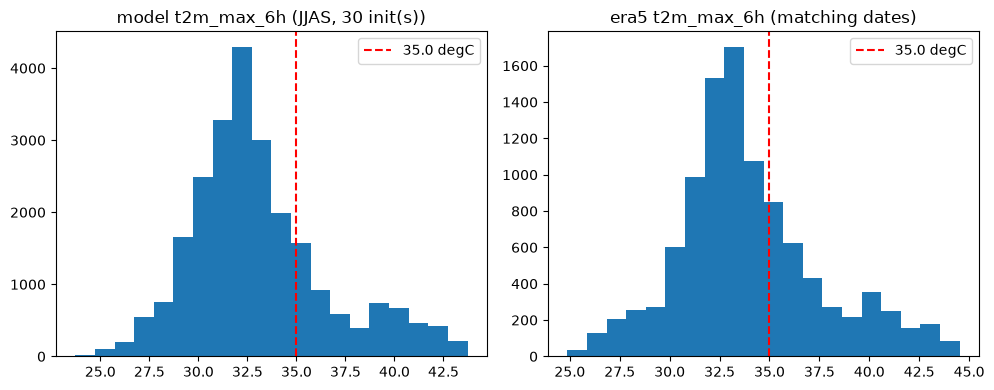

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(model_var_sample.values.flatten(), bins=20)
axes[0].axvline(absolute_threshold, color="red", linestyle="--", label=f"{absolute_threshold} degC")
axes[0].set_title(f"model {variable} (JJAS, {model_sample.sizes['time']} init(s))")
axes[0].legend()
axes[1].hist(era5_var_sample.values.flatten(), bins=20)
axes[1].axvline(absolute_threshold, color="red", linestyle="--", label=f"{absolute_threshold} degC")
axes[1].set_title(f"era5 {variable} (matching dates)")
axes[1].legend()
fig.tight_layout()

## Step 4: Calculate H, M, F, C

`calculate_scores` returns, per initialization batch: unreduced
hit/miss/false-alarm/correct-negative indicators for the absolute threshold
(prefixed `absolute_*`), plus the same for the relative threshold
(prefixed `relative_*`) whenever `has_relative_climatology` is true (Step 2)
-- merged into one `Dataset` via `xr.merge`. RMSE's `squared_error` term is
still commented out (uncomment it, and the `rmse_*` lines in Step 5/7, to
bring that back).

`mean_in_time_batches` reduces only over `"time"` (the initializations),
keeping `prediction_timedelta`, `latitude`, and `longitude` -- i.e. one
global map per lead time, not a single lead-time-averaged map. It processes
one initialization at a time (`batch_size=1`) specifically so the full
multi-year, global, 6-hourly archive never needs to fit in memory at once --
see the earlier discussion of why this batching exists at all.

**Cached to disk** at `by_lead_map_cache_path` after the first run, since
this batching pass is still the expensive part of the notebook even with
climatology skipped. Re-running this cell (or the whole notebook) loads the
cached file instead of recomputing it. To force a fresh recomputation --
e.g. after changing `absolute_threshold`, `variable`, or anything upstream
-- delete that file, or change `by_lead_map_cache_path` in Step 0.

**Timed and logged to `run_timing_log_path`** whenever it actually computes
(not when loading from cache): one row per run recording wall-clock time
alongside the cluster configuration (`n_workers`, `threads_per_worker`,
`memory_limit`) and run parameters, so you can build up a record comparing
configurations over multiple runs rather than a single one-off number.

`prediction_timedelta` is stored as a plain integer lead-day count rather
than relying on `xarray`/`netCDF4`'s `timedelta64` CF encoding: that
round-trip raised `ValueError: failed to prevent overwriting existing key
'dtype' in attrs on variable 'prediction_timedelta'` when actually tested
(xarray 2025.6.1 / netCDF4 1.7.4) -- converting to/from integer days on
either side of `to_netcdf`/`open_dataset` sidesteps it entirely.

In [9]:
def calculate_scores(model_batch: xr.Dataset) -> xr.Dataset:
    # calendar_aligned: bins to lead-day boundaries (0-24h, 24-48h, ...) since
    # initialization, not to whichever step happens to come first in the archive
    # (AIFS-single-v2 has no t+0h step -- see aifs_singlev2.py's docstring for why
    # plain daily_aifs_aggregates()/resample() can't give calendar-aligned bins here).
    model_daily = daily_aifs_aggregates_calendar_aligned(
        model_batch,
        max_days=forecast_days,
    )
    model_var = model_daily[variable]

    absolute_indicators = extreme_indicators(model_var, era5_var, absolute_threshold).rename(
        {name: f"absolute_{name}" for name in ("hits", "misses", "false_alarms", "correct_negatives")}
    )
    scores = absolute_indicators

    if has_relative_climatology:
        relative_threshold = threshold_at_verification_time(threshold_by_doy, model_var)
        relative_indicators = extreme_indicators(model_var, era5_var, relative_threshold).rename(
            {name: f"relative_{name}" for name in ("hits", "misses", "false_alarms", "correct_negatives")}
        )
        scores = xr.merge([absolute_indicators, relative_indicators])

    # scores["squared_error"] = squared_error(model_var, era5_var)  # RMSE commented out for now
    return scores.drop_vars("verification_time", errors="ignore")


def log_run_timing(elapsed_seconds: float) -> None:
    """Append one row to run_timing_log_path recording this run's wall-clock
    time alongside the cluster configuration and run parameters, so runs can
    be compared over time (e.g. different regions, year ranges, or n_workers)."""
    row = {
        "timestamp": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "region_label": region_label,
        "test_year_start": test_year_start,
        "test_year_end": test_year_end,
        "n_initializations": model_test_year.sizes["time"],
        "n_lead_days": len(lead_days_to_plot),
        "variable": variable,
        "absolute_threshold": absolute_threshold,
        "relative_percentile": relative_percentile if has_relative_climatology else None,
        "n_workers": n_workers,
        "threads_per_worker": threads_per_worker,
        "memory_limit": memory_limit,
        "elapsed_seconds": round(elapsed_seconds, 1),
    }
    write_header = not run_timing_log_path.exists()
    with open(run_timing_log_path, "a", newline="") as log_file:
        writer = csv.DictWriter(log_file, fieldnames=list(row))
        if write_header:
            writer.writeheader()
        writer.writerow(row)
    print(f"Logged run timing to {run_timing_log_path}: {row}")


if by_lead_map_cache_path.exists():
    by_lead_map = xr.open_dataset(by_lead_map_cache_path)
    # Cached prediction_timedelta was saved as plain integer lead-days (see markdown
    # above for why) -- convert back to timedelta64 to match the rest of the notebook.
    by_lead_map = by_lead_map.assign_coords(
        prediction_timedelta=(by_lead_map["prediction_timedelta"].values * np.timedelta64(1, "D")).astype(
            "timedelta64[ns]"
        )
    )
    # Fail loudly here, not later as a cryptic KeyError from .sel(): a cache written
    # by an earlier run with different forecast_days/lead_days_to_plot (e.g. before
    # this config changed, even under the same region_label/variable) can
    # silently be missing a lead day this run wants.
    cached_leads = set(by_lead_map["prediction_timedelta"].values)
    wanted_leads = {np.timedelta64(day, "D").astype("timedelta64[ns]") for day in lead_days_to_plot}
    missing_leads = sorted(wanted_leads - cached_leads)
    if missing_leads:
        raise ValueError(
            f"{by_lead_map_cache_path} is stale: missing lead day(s) {missing_leads} "
            f"(cached file only has {sorted(cached_leads)}). It was likely written by a "
            "run with different forecast_days/lead_days_to_plot. Delete this file "
            "(by_lead_map_cache_path.unlink()) and re-run this cell."
        )
else:
    start_time = time.perf_counter()

    initialization_batch_size = 1
    summaries = mean_in_time_batches(
        model_test_year,
        calculate_scores,
        reductions={"by_lead_map": ("time",)},
        batch_size=initialization_batch_size,
    )
    by_lead_map = summaries["by_lead_map"]

    elapsed_seconds = time.perf_counter() - start_time
    log_run_timing(elapsed_seconds)

    # Save prediction_timedelta as plain integer lead-days, not timedelta64 -- see
    # markdown above for the netCDF encoding error this sidesteps.
    by_lead_map_to_save = by_lead_map.assign_coords(
        prediction_timedelta=(by_lead_map["prediction_timedelta"] / np.timedelta64(1, "D")).astype(int)
    )
    by_lead_map_to_save.to_netcdf(by_lead_map_cache_path)

by_lead_map

/tmp/ipykernel_2094331/988027234.py:22: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  scores = xr.merge([absolute_indicators, relative_indicators])


/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


/tmp/ipykernel_2094331/988027234.py:22: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  scores = xr.merge([absolute_indicators, relative_indicators])


/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


/tmp/ipykernel_2094331/988027234.py:22: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  scores = xr.merge([absolute_indicators, relative_indicators])


...

/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


/tmp/ipykernel_2094331/988027234.py:22: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  scores = xr.merge([absolute_indicators, relative_indicators])


/home/xuanji/.conda/envs/heat-extremes/lib/python3.11/site-packages/zarr/codecs/numcodecs/_codecs.py:163: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


Logged run timing to run_timings.csv: {'timestamp': '2026-07-27T04:48:20+00:00', 'region_label': 'region_27.50_29.50_76.50_78.50', 'test_year_start': 2022, 'test_year_end': 2022, 'n_initializations': 91, 'n_lead_days': 5, 'variable': 't2m_max_6h', 'absolute_threshold': 35.0, 'relative_percentile': 0.95, 'n_workers': 32, 'threads_per_worker': 1, 'memory_limit': '8GiB', 'elapsed_seconds': 266.3}


<xarray.Dataset> Size: 52kB
Dimensions:                     (latitude: 9, longitude: 9,
                                 prediction_timedelta: 10)
Coordinates:
  * latitude                    (latitude) float64 72B 29.5 29.25 ... 27.75 27.5
  * longitude                   (longitude) float64 72B 76.5 76.75 ... 78.5
  * prediction_timedelta        (prediction_timedelta) timedelta64[ns] 80B 1 ...
Data variables:
    absolute_hits               (prediction_timedelta, latitude, longitude) float64 6kB ...
    absolute_misses             (prediction_timedelta, latitude, longitude) float64 6kB ...
    absolute_false_alarms       (prediction_timedelta, latitude, longitude) float64 6kB ...
    absolute_correct_negatives  (prediction_timedelta, latitude, longitude) float64 6kB ...
    relative_hits               (prediction_timedelta, latitude, longitude) float64 6kB ...
    relative_misses             (prediction_timedelta, latitude, longitude) float64 6kB ...
    relative_false_alarms       (prediction_timedelta, latitude, longitude) float64 6kB ...
    relative_correct_negatives  (prediction_timedelta, latitude, longitude) float64 6kB ...

## Step 5: Calculate POD, FAR, SEDI

`by_lead_map` holds batch-averaged (not summed) indicators; because these
are means of 0/1 indicators rather than raw counts, the rate functions
(`probability_of_detection`, etc.) give identical results to computing them
from summed contingency counts directly (see `deterministic_metrics.py`'s
module docstring). `finish_event_scores` is called once for `"absolute"`,
and again for `"relative"` whenever `has_relative_climatology` is true.
(RMSE is still commented out -- uncomment along with `squared_error` above
to bring it back.)

**Lead-day bins are calendar-aligned** (0-24h, 24-48h, ... since
initialization), via `aifs_singlev2.daily_aifs_aggregates_calendar_aligned`
(see its docstring): AIFS-single-v2 has no t+0h step, so the plain
`resample(...).mean()` used by `daily_aifs_aggregates` anchors bins to
whichever step comes first in the archive -- 6h, 30h, 54h, ... -- not to
lead time zero. `daily_aifs_aggregates_calendar_aligned` bins explicitly via
`floor(step / 1 day) + 1` instead, so `prediction_timedelta` labels land
exactly on `1 days`, `2 days`, `3 days`, .... The `+1` (end-of-window, not
start-of-window) and the calendar alignment itself both match the real
store's own `prediction_timedelta_daily` coordinate -- confirmed directly
against the real AIFS-single-v2 `Dataset` repr, which backs
`total_precipitation`'s daily dimension with exactly this convention
(`N days` = window `[(N-1)*24h, N*24h)`; `2m_temperature` itself is only
stored 6-hourly, so it still needs aggregating here, just consistently with
how precipitation is already labeled in the same store). One caveat this
doesn't remove: **day 1 is a partial bin** (3 of the usual 4 six-hourly
samples -- 6h, 12h, 18h -- since there's no 0h sample to fill the first
slot); every day after that is a complete 4-sample bin.

`select_by_lead_day` below still selects with `method="nearest"` (12-hour
`tolerance`) rather than an exact match, as a defensive fallback -- with
calendar-aligned bins this should always match exactly, but if a lead day is
ever genuinely missing (e.g. a short rollout), this raises a clear error
instead of a silent mismatch.

In [10]:
def finish_event_scores(means: xr.Dataset, prefix: str) -> xr.Dataset:
    """POD/miss-rate/FAR/POFD/SEDI for one threshold definition's indicator means."""
    counts = means[[f"{prefix}_{name}" for name in ("hits", "misses", "false_alarms", "correct_negatives")]]
    counts = counts.rename({f"{prefix}_{name}": name for name in ("hits", "misses", "false_alarms", "correct_negatives")})
    pod = probability_of_detection(counts)
    return xr.Dataset(
        {
            "pod": pod,
            "miss_rate": 1 - pod,
            "far": false_alarm_ratio(counts),
            "pofd": probability_of_false_detection(counts),
            "sedi": symmetric_extremal_dependence_index(counts),
        }
    )


def select_by_lead_day(scores: xr.Dataset, lead_days: list[int]) -> xr.Dataset:
    """Select the nearest available prediction_timedelta bin to each nominal lead
    day, then relabel the coordinate to the clean nominal day (see markdown above:
    with calendar-aligned bins this should always match exactly; nearest+tolerance
    is a defensive fallback, not a fix for a known offset)."""
    lead_timedeltas = np.array(lead_days).astype("timedelta64[D]").astype("timedelta64[ns]")
    selected = scores.sel(
        prediction_timedelta=lead_timedeltas, method="nearest", tolerance=np.timedelta64(12, "h")
    )
    return selected.assign_coords(prediction_timedelta=lead_timedeltas)


# rmse_map = rmse_from_mean_squared_error(by_lead_map["squared_error"]).rename("rmse")  # RMSE commented out for now
absolute_scores = finish_event_scores(by_lead_map, "absolute")
absolute_by_lead = select_by_lead_day(absolute_scores, lead_days_to_plot)

# rmse_by_lead = select_by_lead_day(rmse_map, lead_days_to_plot)  # RMSE commented out for now

if has_relative_climatology:
    relative_scores = finish_event_scores(by_lead_map, "relative")
    relative_by_lead = select_by_lead_day(relative_scores, lead_days_to_plot)
else:
    relative_scores = None
    relative_by_lead = None

absolute_by_lead

<xarray.Dataset> Size: 16kB
Dimensions:               (latitude: 9, longitude: 9, prediction_timedelta: 5)
Coordinates:
  * latitude              (latitude) float64 72B 29.5 29.25 29.0 ... 27.75 27.5
  * longitude             (longitude) float64 72B 76.5 76.75 77.0 ... 78.25 78.5
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 40B 1 days ....
Data variables:
    pod                   (prediction_timedelta, latitude, longitude) float64 3kB ...
    miss_rate             (prediction_timedelta, latitude, longitude) float64 3kB ...
    far                   (prediction_timedelta, latitude, longitude) float64 3kB ...
    pofd                  (prediction_timedelta, latitude, longitude) float64 3kB ...
    sedi                  (prediction_timedelta, latitude, longitude) float64 3kB ...

## Step 6: Sanity checks

Cheap checks on the results themselves, before reading too much into the
maps in Step 7:

1. **The four categories should sum to ~1** at every valid cell (`by_lead_map`
   holds means of mutually-exclusive, exhaustive 0/1 indicators).
2. **Range check**: POD/FAR/POFD in `[0, 1]`, SEDI in `[-1, 1]`.
3. **Skill should not improve with lead time.** POD/SEDI should trend down
   (or stay flat) from the shortest to the longest lead day plotted, FAR up
   or flat -- a strong reversal is a red flag, not just an odd result.
4. **NaN fraction**: how much of the map is actually defined. If POD/FAR are
   only defined over a tiny sliver, the maps in Step 7 are mostly
   sample-size noise, not signal.

In [11]:
# Run every check for "absolute", and again for "relative" if it's active --
# same checks, just per threshold definition, since by_lead_map/*_scores/*_by_lead
# hold both independently.
scores_by_prefix = {"absolute": absolute_scores}
by_lead_by_prefix = {"absolute": absolute_by_lead}
if has_relative_climatology:
    scores_by_prefix["relative"] = relative_scores
    by_lead_by_prefix["relative"] = relative_by_lead

# 1. Four categories sum to ~1
for prefix in scores_by_prefix:
    category_total = sum(
        by_lead_map[f"{prefix}_{name}"] for name in ("hits", "misses", "false_alarms", "correct_negatives")
    )
    print(f"[{prefix}] category sum -- min:", float(category_total.min()), "max:", float(category_total.max()), "(expect ~1.0, or NaN)")
print()

# 2. Range check
for prefix, scores in scores_by_prefix.items():
    for name in ("pod", "far", "pofd", "sedi"):
        values = scores[name]
        print(f"[{prefix}] {name}: min={float(values.min()):.3f} max={float(values.max()):.3f}")
print()

# 3. Trend across lead days (only informative with more than one lead day plotted)
print("spatial-mean by lead day (days:", lead_days_to_plot, "):")
for prefix, by_lead in by_lead_by_prefix.items():
    for name in ("pod", "far", "sedi"):
        means = by_lead[name].mean(dim=["latitude", "longitude"], skipna=True)
        print(f"  [{prefix}] {name}:", [round(float(v), 3) for v in means.values])
print()

# 4. NaN fraction
for prefix, by_lead in by_lead_by_prefix.items():
    valid_fraction = by_lead["pod"].notnull().mean(dim=["latitude", "longitude"])
    print(f"[{prefix}] fraction of map with a defined POD, by lead day:", [round(float(v), 3) for v in valid_fraction.values])

[absolute] category sum -- min: 0.9999999999999999 max: 1.0 (expect ~1.0, or NaN)
[relative] category sum -- min: 1.0 max: 1.0 (expect ~1.0, or NaN)

[absolute] pod: min=0.353 max=1.000
[absolute] far: min=0.000 max=0.250
[absolute] pofd: min=0.000 max=0.108
[absolute] sedi: min=0.636 max=0.986
[relative] pod: min=nan max=nan
[relative] far: min=nan max=nan
[relative] pofd: min=0.000 max=0.000
[relative] sedi: min=nan max=nan

spatial-mean by lead day (days: [1, 3, 5, 7, 9] ):
  [absolute] pod: [0.853, 0.756, 0.797, 0.848, 0.818]
  [absolute] far: [0.097, 0.076, 0.066, 0.052, 0.08]
  [absolute] sedi: [0.927, 0.885, 0.911, 0.936, 0.909]
  [relative] pod: [nan, nan, nan, nan, nan]
  [relative] far: [nan, nan, nan, nan, nan]
  [relative] sedi: [nan, nan, nan, nan, nan]

[absolute] fraction of map with a defined POD, by lead day: [1.0, 1.0, 1.0, 1.0, 1.0]
[relative] fraction of map with a defined POD, by lead day: [0.0, 0.0, 0.0, 0.0, 0.0]


## Step 7: Plotting

One figure for the absolute threshold's POD / FAR / SEDI (3 rows x N lead
days), and a second, identically-laid-out figure for the relative threshold
whenever `has_relative_climatology` is true (skipped, with a printed message
instead, when it isn't -- e.g. `variable = "t2m_mean_6h"`). RMSE's figure is
still commented out for now (`plot_metric_grid` itself is still
defined/used below, just not called for RMSE).

Each figure is also saved as a PNG (filename includes `region_label`,
`variable`, and -- for the relative figure -- the percentile used, so plots
from different regions, year ranges, variables, or percentiles never
overwrite each other), so you have the maps as a persistent file without
re-running the notebook.

In [12]:
def plot_metric_grid(
    data_by_row: dict[str, tuple[xr.DataArray, dict]],
    lead_days: list[int],
    suptitle: str,
    region_bounds: tuple[float, float, float, float] | None = None,
):
    """data_by_row: {row_label: (DataArray with a prediction_timedelta dim, plot_kwargs)}.

    region_bounds: (south, north, west, east) -- same convention as
    subset_region(). Pass the notebook's region_bounds here to zoom the map to
    that box instead of the whole globe -- when the data only covers a small
    region, set_global() would draw the entire world with the actual (tiny)
    data patch invisible at that scale. Leave as None for the global run.
    """
    n_rows = len(data_by_row)
    n_cols = len(lead_days)
    figure, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols, figsize=(4 * n_cols, 3 * n_rows),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
    )
    for row, (row_label, (data, plot_kwargs)) in enumerate(data_by_row.items()):
        for col, lead in enumerate(lead_days):
            axis = axes[row, col]
            lead_timedelta = np.timedelta64(lead, "D")
            data.sel(prediction_timedelta=lead_timedelta).plot(
                ax=axis, x="longitude", y="latitude", transform=ccrs.PlateCarree(),
                add_colorbar=(col == n_cols - 1), cbar_kwargs={"label": row_label} if col == n_cols - 1 else None,
                **plot_kwargs,
            )
            if region_bounds is not None:
                south, north, west, east = region_bounds
                axis.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
            else:
                axis.set_global()
            axis.coastlines(linewidth=0.5)
            axis.set_title(f"{row_label}, lead={lead}d" if row == 0 else f"lead={lead}d")
    figure.suptitle(suptitle)
    figure.tight_layout()
    return figure


# RMSE commented out for now -- uncomment (and the rmse_map/rmse_by_lead lines in Step 5) to bring it back:
# rmse_figure = plot_metric_grid(
#     {"RMSE": (rmse_by_lead, {"cmap": "magma_r", "vmin": 0})},
#     lead_days_to_plot,
#     f"AIFS-single-v2 vs ERA5, {variable}, {test_year_start}-{test_year_end} -- RMSE",
#     region_bounds=region_bounds,
# )
# rmse_figure.savefig(f"aifs_singlev2_rmse_maps_{test_year_start}_{test_year_end}_{region_label}_{variable}.png", dpi=150)

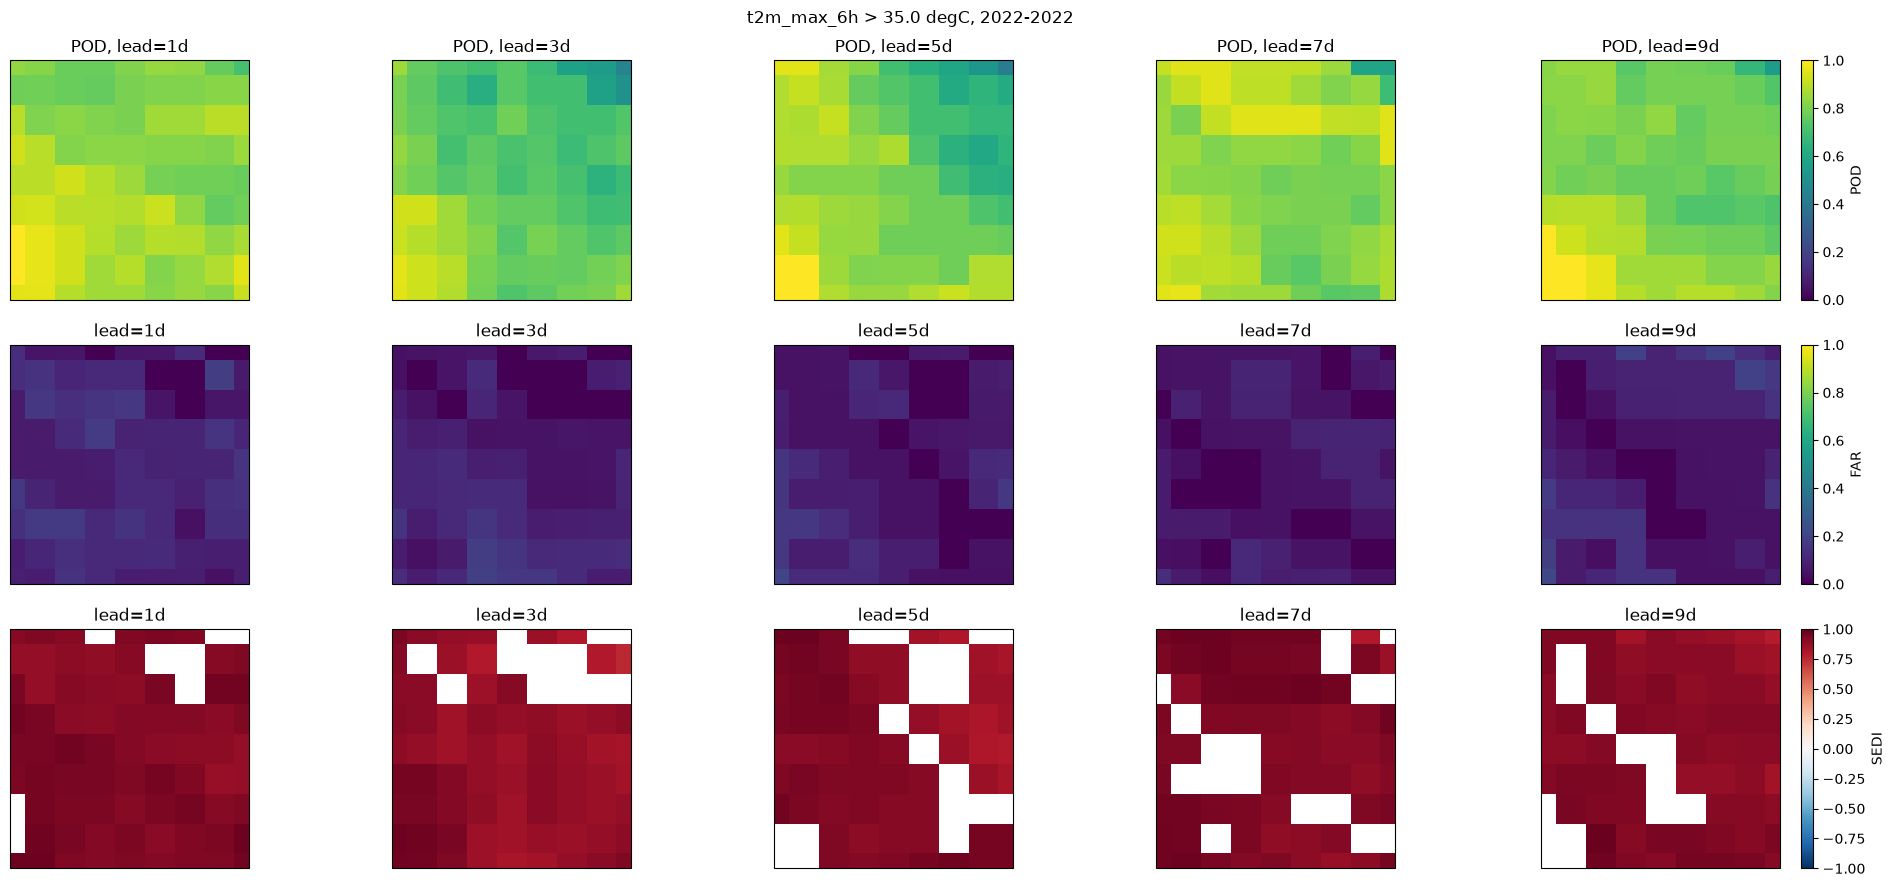

In [13]:
absolute_figure = plot_metric_grid(
    {
        "POD": (absolute_by_lead["pod"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
        "FAR": (absolute_by_lead["far"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
        "SEDI": (absolute_by_lead["sedi"], {"cmap": "RdBu_r", "vmin": -1, "vmax": 1}),
    },
    lead_days_to_plot,
    f"{variable} > {absolute_threshold} degC, {test_year_start}-{test_year_end}",
    region_bounds=region_bounds,
)
absolute_figure.savefig(f"aifs_singlev2_absolute_maps_{test_year_start}_{test_year_end}_{region_label}_{variable}.png", dpi=150)

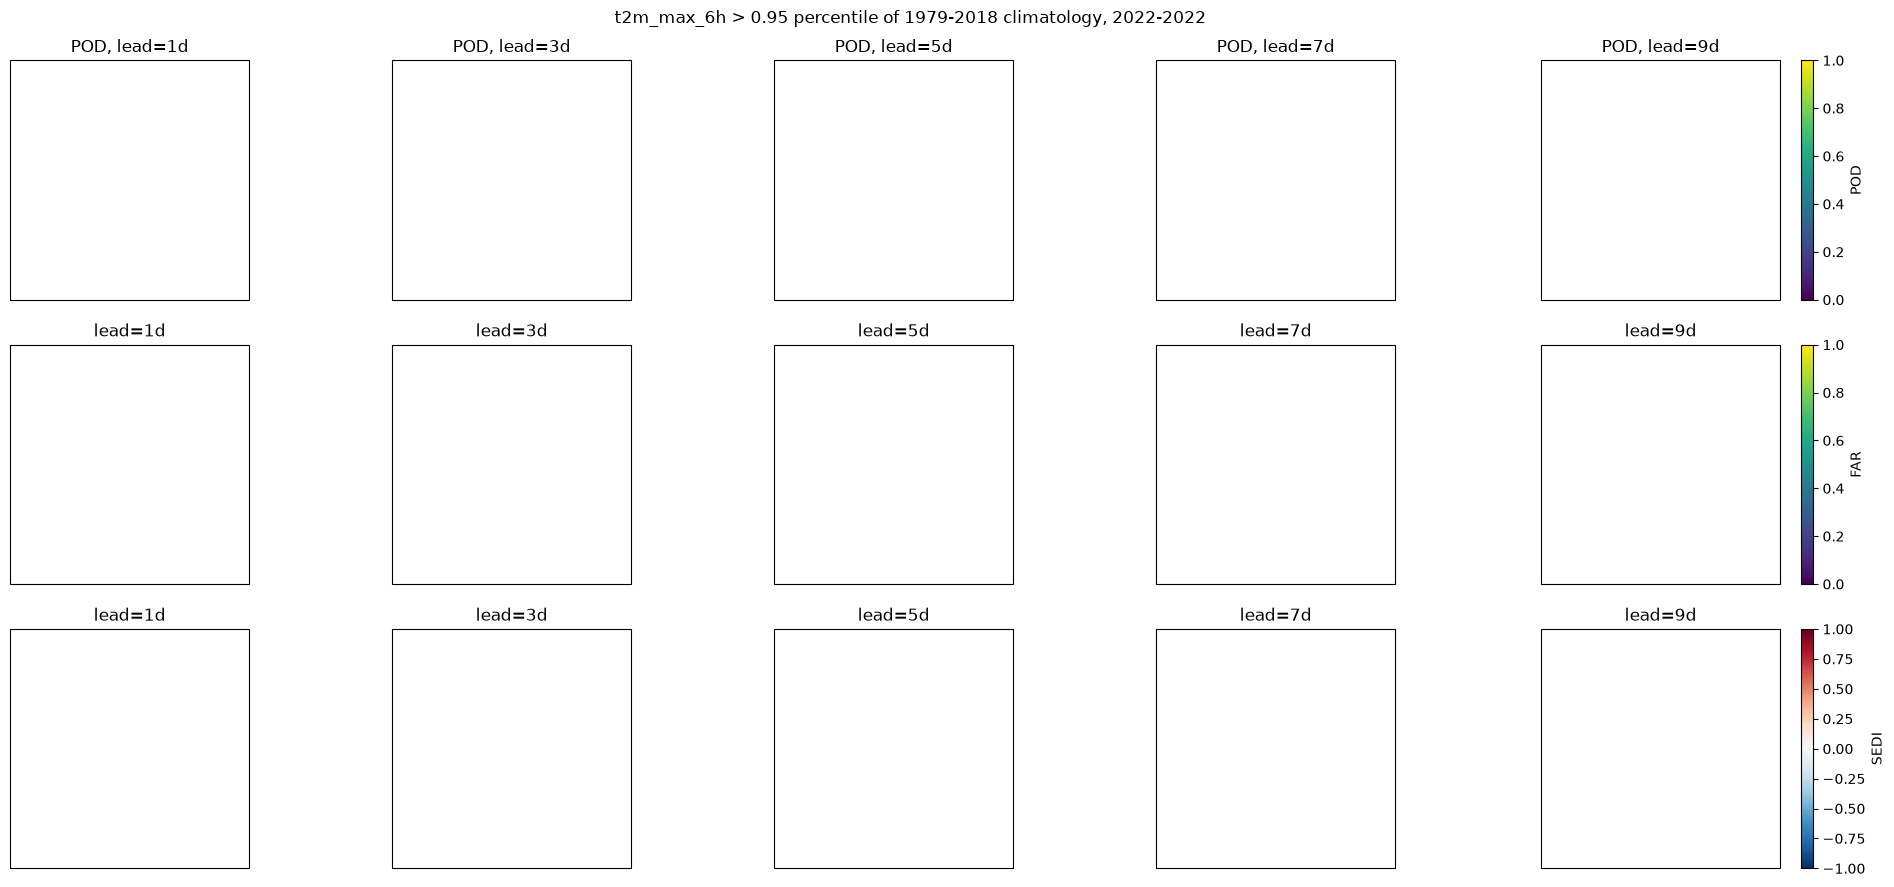

In [14]:
if has_relative_climatology:
    relative_figure = plot_metric_grid(
        {
            "POD": (relative_by_lead["pod"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
            "FAR": (relative_by_lead["far"], {"cmap": "viridis", "vmin": 0, "vmax": 1}),
            "SEDI": (relative_by_lead["sedi"], {"cmap": "RdBu_r", "vmin": -1, "vmax": 1}),
        },
        lead_days_to_plot,
        f"{variable} > {relative_percentile} percentile of 1979-2018 climatology, {test_year_start}-{test_year_end}",
        region_bounds=region_bounds,
    )
    relative_figure.savefig(
        f"aifs_singlev2_relative_maps_{test_year_start}_{test_year_end}_{region_label}_{variable}_{relative_label}.png",
        dpi=150,
    )
else:
    print(f"No relative threshold for variable={variable!r} (no precomputed climatology) -- skipping relative maps.")

In [20]:
variable = "t2m_mean_6h"
has_absolute_threshold =  (variable != "total_precipitation" and variable != "t2m_max_6h" and variable != "t2m_min_6h")



In [21]:
has_absolute_threshold

True